# Notebook 2 — Entraînement et évaluation du modèle Naive Bayes

## Objectif
Ce notebook entraîne un modèle de **Naive Bayes gaussien** à partir du dataset `processed` préparé dans le notebook précédent, puis évalue sa capacité à prédire le genre principal d'un film.

## Jeu de données utilisé
Le fichier d'entrée attendu est :

```text
data/processed/imdb_genre_nb_ready.csv
```

Il contient :
- `No_of_Votes`
- `IMDB_Rating`
- `Meta_score`
- `Genre`
- `Genre_encoded`

## Démarche
1. chargement des données traitées ;
2. séparation des variables explicatives et de la cible ;
3. découpage en jeu d'entraînement et jeu de test ;
4. entraînement du modèle `GaussianNB` ;
5. prédictions ;
6. évaluation par accuracy, précision, rappel et F1-score ;
7. lecture métier et méthodologique des résultats ;
8. sauvegarde du modèle et des métriques.


In [1]:
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Définition des chemins

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROCESSED_DIR / "imdb_genre_nb_ready.csv"
MAPPING_PATH = PROCESSED_DIR / "genre_label_mapping.csv"

DATA_PATH, MAPPING_PATH

(WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/data/processed/imdb_genre_nb_ready.csv'),
 WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/data/processed/genre_label_mapping.csv'))

## 2. Chargement du dataset processed

In [3]:
df = pd.read_csv(DATA_PATH)
label_mapping = pd.read_csv(MAPPING_PATH)

print(f"Dimensions du dataset processed : {df.shape}")
display(df.head())
display(label_mapping)

Dimensions du dataset processed : (675, 5)


,No_of_Votes,IMDB_Rating,Meta_score,Genre,Genre_encoded
0,2343110,9.300,80.000,Drama,4
1,1620367,9.200,100.000,Crime,3
2,2303232,9.000,84.000,Action,0
3,1129952,9.000,90.000,Crime,3
4,689845,9.000,96.000,Crime,3


,Genre,Genre_encoded
0,Action,0
1,Biography,1
2,Comedy,2
3,Crime,3
4,Drama,4


## 3. Définition des variables explicatives et de la cible

Le sujet impose une prédiction du genre à partir de variables numériques.  
On retient donc :

- `No_of_Votes`
- `IMDB_Rating`
- `Meta_score`

comme variables explicatives, et :

- `Genre_encoded`

comme variable cible.


In [4]:
feature_columns = ["No_of_Votes", "IMDB_Rating", "Meta_score"]
target_column = "Genre_encoded"

X = df[feature_columns]
y = df[target_column]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
display(X.head())

Dimensions de X : (675, 3)
Dimensions de y : (675,)


,No_of_Votes,IMDB_Rating,Meta_score
0,2343110,9.300,80.000
1,1620367,9.200,100.000
2,2303232,9.000,84.000
3,1129952,9.000,90.000
4,689845,9.000,96.000


## 4. Séparation en jeu d'entraînement et jeu de test

On utilise ici un découpage classique :
- **80 %** pour l'entraînement ;
- **20 %** pour le test.

Le paramètre `stratify=y` permet de conserver une répartition cohérente des classes entre apprentissage et test.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (540, 3) (540,)
Test  : (135, 3) (135,)


## 5. Entraînement du modèle Naive Bayes

Le choix retenu est `GaussianNB` car les variables d'entrée sont numériques continues.


In [6]:
model = GaussianNB()
model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


## 6. Prédictions sur le jeu de test

In [7]:
y_pred = model.predict(X_test)

predictions_preview = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred
})
predictions_preview.head(10)

,y_true,y_pred
0,4,4
1,3,4
2,1,4
3,2,4
4,0,4
5,2,4
6,1,4
7,4,4
8,1,4
9,4,4


## 7. Évaluation globale

On calcule les métriques principales :
- accuracy ;
- précision macro ;
- rappel macro ;
- F1-score macro.

Le choix du mode `macro` permet de donner le même poids à chaque genre, ce qui est pertinent dans un contexte multiclasses.


In [8]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
}

metrics

{'accuracy': 0.35555555555555557,
 'precision_macro': 0.13476890756302523,
 'recall_macro': 0.21364942528735634,
 'f1_macro': 0.14743845642049236}

In [9]:
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

accuracy: 0.3556
precision_macro: 0.1348
recall_macro: 0.2136
f1_macro: 0.1474


## 8. Rapport de classification détaillé

Ce tableau permet d'évaluer les performances **genre par genre**.


In [10]:
target_names = label_mapping.sort_values("Genre_encoded")["Genre"].tolist()

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
Action,0.312,0.172,0.222,29.000
Biography,0.000,0.000,0.000,16.000
Comedy,0.000,0.000,0.000,25.000
Crime,0.000,0.000,0.000,17.000
Drama,0.361,0.896,0.515,48.000
accuracy,0.356,0.356,0.356,0.356
macro avg,0.135,0.214,0.147,135.000
weighted avg,0.196,0.356,0.231,135.000


## 9. Matrice de confusion

La matrice de confusion permet de visualiser :
- les genres correctement prédits ;
- les genres fréquemment confondus ;
- les zones de faiblesse du modèle.


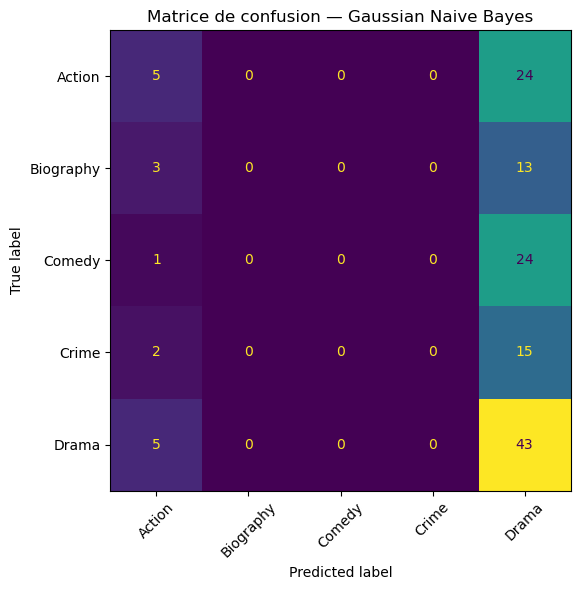

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matrice de confusion — Gaussian Naive Bayes")
plt.tight_layout()
plt.show()

## 10. Lecture analytique des résultats

### Interprétation attendue
Dans ce projet, il est normal que les performances restent modérées, car :
1. les variables explicatives sont limitées à trois indicateurs numériques ;
2. ces variables ne décrivent pas directement le contenu narratif ou stylistique d'un film ;
3. certains genres peuvent partager des profils statistiques proches ;
4. Naive Bayes repose sur une hypothèse d'indépendance conditionnelle simplificatrice.

### Ce qu'il faudra expliquer dans le rapport
Une conclusion rigoureuse peut être formulée ainsi :

> Les résultats obtenus montrent que les variables numériques disponibles ne suffisent pas à discriminer parfaitement les genres de films. Le modèle parvient à capter certains profils statistiques, mais la prédiction du genre reste un problème complexe, car le genre dépend aussi d'éléments sémantiques, narratifs et contextuels absents des variables utilisées ici.

### Limites méthodologiques à mentionner
- simplification du genre à une seule étiquette principale ;
- exclusion des genres rares ;
- absence de variables textuelles comme `Overview` ;
- absence de variables supplémentaires comme une vraie mesure de popularité.


## 11. Sauvegarde du modèle et des résultats

On sauvegarde :
- le modèle entraîné ;
- les métriques principales ;
- le rapport de classification détaillé.


In [12]:
model_path = MODELS_DIR / "gaussian_nb_imdb_genre.joblib"
metrics_path = REPORTS_DIR / "gaussian_nb_metrics.json"
report_path = REPORTS_DIR / "gaussian_nb_classification_report.csv"

joblib.dump(model, model_path)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

report_df.to_csv(report_path, index=True)

print(f"Modèle sauvegardé : {model_path}")
print(f"Métriques sauvegardées : {metrics_path}")
print(f"Rapport détaillé sauvegardé : {report_path}")

Modèle sauvegardé : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\models\gaussian_nb_imdb_genre.joblib
Métriques sauvegardées : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\reports\gaussian_nb_metrics.json
Rapport détaillé sauvegardé : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\reports\gaussian_nb_classification_report.csv


## 12. Conclusion

Ce notebook a permis de :
- charger le dataset `processed` ;
- entraîner un modèle `GaussianNB` ;
- produire des prédictions sur un jeu de test ;
- mesurer les performances globales et détaillées ;
- sauvegarder le modèle et les principaux livrables.

La chaîne de travail est maintenant structurée en deux blocs distincts :
1. **préparation des données** ;
2. **entraînement / évaluation du modèle**.

C'est une organisation propre, professionnelle et reproductible pour un projet académique de machine learning.
